### Retrieving the results of the training to make predictions on the test dataset and display the confusion matrix an the interpretation tools

In [3]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification, DataCollatorWithPadding
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap
import os


In [4]:
labels      = [ "Self-direction: thought", "Self-direction: action", "Stimulation",  "Hedonism", "Achievement", "Power: dominance", "Power: resources", "Face", "Security: personal", "Security: societal", "Tradition", "Conformity: rules", "Conformity: interpersonal", "Humility", "Benevolence: caring", "Benevolence: dependability", "Universalism: concern", "Universalism: nature", "Universalism: tolerance", "No Value"]
num_labels  = len(labels)

train_dataset       = datasets.load_from_disk("../datasets/processed_train")
validation_dataset  = datasets.load_from_disk("../datasets/processed_validation")
test_dataset        = datasets.load_from_disk("../datasets/processed_test")

In [5]:
model       = RobertaForSequenceClassification.from_pretrained(r"C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\checkpoint-11190-20250306T093724Z-001\checkpoint-11190", num_labels = num_labels)
tokenizer   = RobertaTokenizer.from_pretrained(r"C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\tokenizer-20250306T094027Z-001\tokenizer")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\checkpoint-11190-20250306T093724Z-001\checkpoint-11190 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

### Confusion matrix :

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def dataset_to_dataloader(encoded_dataset, batch_size=8):
    return DataLoader(encoded_dataset, batch_size=batch_size, collate_fn=data_collator)

test_dataloader = dataset_to_dataloader(test_dataset)

all_logits = []
all_true_labels = []

for batch in test_dataloader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = torch.tensor(batch["labels"]).to(device)  # Extract true labels

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs[0]
        all_logits.append(logits.cpu().numpy())
        all_true_labels.append(labels.cpu().numpy())

# Concatenate logits and true labels
all_logits = np.concatenate(all_logits, axis=0)
all_true_labels = np.concatenate(all_true_labels, axis=0)

In [ ]:
# Convert logits to probabilities
probs = torch.sigmoid(torch.tensor(all_logits))

threshold = 0.5  # or any other chosen threshold
predicted_labels = (probs >= threshold).int().numpy()

num_labels = all_true_labels.shape[1]
global_conf_matrix = np.zeros((num_labels, num_labels), dtype=int)

# Compute confusion matrix per label (TP, FP, TN, FN)
for label_idx in range(num_labels):
    # Get true and predicted values for the current label
    true_label = all_true_labels[:, label_idx]
    pred_label = predicted_labels[:, label_idx]
    
    # Compute confusion matrix for the current label
    # cm = confusion_matrix(true_label, pred_label)
    tp = ((true_label == 1) & (pred_label == 1)).sum()  # True positives
    fp = ((true_label == 0) & (pred_label == 1)).sum()  # False positives
    tn = ((true_label == 0) & (pred_label == 0)).sum()  # True negatives
    fn = ((true_label == 1) & (pred_label == 0)).sum()  # False negatives
    
    # Store the confusion matrix (TP, FP, TN, FN) for the current label
    global_conf_matrix[label_idx, label_idx] = tp  # Diagonal represents true positives
    global_conf_matrix[label_idx, (label_idx + 1) % num_labels] = fp  # Store FP
    global_conf_matrix[(label_idx + 1) % num_labels, label_idx] = fn  # Store FN
    global_conf_matrix[(label_idx + 1) % num_labels, (label_idx + 1) % num_labels] = tn

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(global_conf_matrix, xticklabels=labels, yticklabels=labels, annot=True, fmt='d', cmap="Blues")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Global Confusion Matrix')
plt.show()

### Explainability :

In [12]:
def predict(texts):
    tokens = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**tokens)
    return outputs.logits.numpy()

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict,masker)

In [7]:
# que mettre comme chemin pour le file des labels ???
def load_dataset(directory, load_labels=True):
    sentences_file_path = os.path.join(directory, "sentences.tsv")
    labels_file_path = os.path.join(directory, "values_labels.tsv")
    
    data_frame = pd.read_csv(sentences_file_path, encoding="utf-8", sep="\t", header=0)

    if load_labels and os.path.isfile(labels_file_path):
        labels_frame = pd.read_csv(labels_file_path, encoding="utf-8", sep="\t", header=0)
        labels_frame = pd.merge(data_frame, labels_frame, on=["Text-ID", "Sentence-ID"], how="inner")
       
    
    return labels_frame

In [8]:
directory_train="../datasets/valueeval24/test-english"
data = load_dataset(directory_train)

In [9]:
data["Text"][:3].tolist()

['Spain’s minister pleads for ‘millions and millions’ of immigrants',
 'Madrid.',
 '“The demographic trajectories are there.']

Visualise the impact of each word for the output classes

In [10]:
l=data["Text"].tolist()

In [11]:
id2label = {i: labels[i] for i in range(len(labels))}
print(id2label)
model.config.id2label = id2label
model.config.id2label


{0: 'Self-direction: thought', 1: 'Self-direction: action', 2: 'Stimulation', 3: 'Hedonism', 4: 'Achievement', 5: 'Power: dominance', 6: 'Power: resources', 7: 'Face', 8: 'Security: personal', 9: 'Security: societal', 10: 'Tradition', 11: 'Conformity: rules', 12: 'Conformity: interpersonal', 13: 'Humility', 14: 'Benevolence: caring', 15: 'Benevolence: dependability', 16: 'Universalism: concern', 17: 'Universalism: nature', 18: 'Universalism: tolerance', 19: 'No Value'}


{0: 'Self-direction: thought',
 1: 'Self-direction: action',
 2: 'Stimulation',
 3: 'Hedonism',
 4: 'Achievement',
 5: 'Power: dominance',
 6: 'Power: resources',
 7: 'Face',
 8: 'Security: personal',
 9: 'Security: societal',
 10: 'Tradition',
 11: 'Conformity: rules',
 12: 'Conformity: interpersonal',
 13: 'Humility',
 14: 'Benevolence: caring',
 15: 'Benevolence: dependability',
 16: 'Universalism: concern',
 17: 'Universalism: nature',
 18: 'Universalism: tolerance',
 19: 'No Value'}

The Transformers_interpret explainer

In [12]:
from transformers_interpret import SequenceClassificationExplainer
cls_explainer = SequenceClassificationExplainer(model, tokenizer)

In [144]:
attributions = cls_explainer(l[3])

In [145]:
cls_explainer.visualize()

Tokenizer problem?

In [23]:
text = "j'aime l'école" 
tokens = tokenizer.tokenize(text)

print("Tokens:", tokens)

Tokens: ['j', "'", 'a', 'ime', 'Ġl', "'", 'Ã©', 'co', 'le']


In [18]:
model2       = RobertaForSequenceClassification.from_pretrained(r"C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\checkpoint-11190-20250306T093724Z-001\checkpoint-11190", num_labels = num_labels)
tokenizer2   = RobertaTokenizer.from_pretrained(r"C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\tokenizer-20250306T094027Z-001\tokenizer")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\amine\Downloads\DASCI\Projet Pro Com\exai\checkpoint-11190-20250306T093724Z-001\checkpoint-11190 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
model2.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

Trying Shap

In [24]:
from transformers import  pipeline
classifier = pipeline('text-classification', top_k=3, model=model2,tokenizer=tokenizer2)
classifier(l[:1])


[[{'label': 'LABEL_7', 'score': 0.07409899681806564},
  {'label': 'LABEL_3', 'score': 0.07204529643058777},
  {'label': 'LABEL_19', 'score': 0.06745655834674835}]]

In [25]:
filtered_df = data[data['Humility'] == 1]
liste_h=filtered_df['Text'].tolist()

In [26]:
import shap
explainer = shap.Explainer(classifier)

In [140]:
shap_values = explainer(liste_h[:1])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:51, 51.63s/it]               


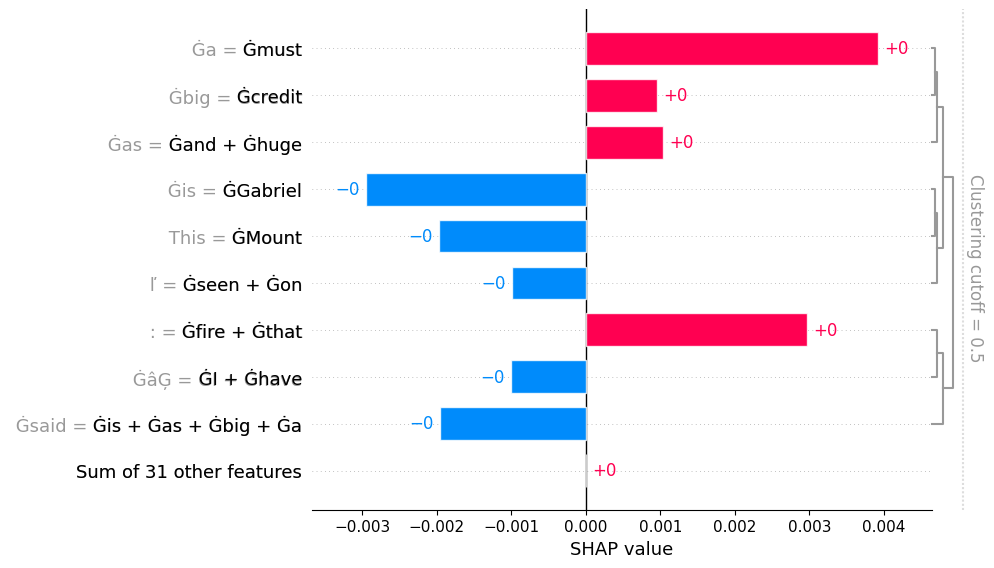

In [141]:
shap_class_13 = shap_values[0][:, 19]  
shap.plots.bar(shap_class_13)

In [7]:
!pip freeze > requirements.txt
